# Práctica 1 - Procesamiento del corpus

El notebook sigue el orden de la rúbrica. Los archivos `.txt` del corpus son la fuente original y no se sobrescriben durante el preprocesamiento.

ola


In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CORPUS_DIR = ROOT / "corpus"
METADATA_PATH = CORPUS_DIR / "metadata.csv"
metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,doc_id,label,source_type,source_name,url,title,date,n_words,topic,file,original_id
0,ds_falso_0001,0,dataset,fuente2_kaggle,NaN,El órgano que fiscaliza al Gobierno andaluz de...,NaN,58,politica,Falso/ds_falso_0001.txt,ID
1,ds_falso_0002,0,dataset,fuente2_kaggle,NaN,PP pide a Cristina Narbona igualar los permiso...,NaN,50,politica,Falso/ds_falso_0002.txt,ID
2,ds_falso_0003,0,dataset,fuente2_kaggle,NaN,Cristina Narbona rebaja las hipótesis electora...,NaN,49,politica,Falso/ds_falso_0003.txt,ID
3,ds_falso_0004,0,dataset,fuente2_kaggle,NaN,"Carrero Blanco, elegida candidata del Iniciati...",NaN,47,politica,Falso/ds_falso_0004.txt,ID
4,ds_falso_0005,0,dataset,fuente2_kaggle,NaN,Diego Cañamero pide aprobar ya los presupuesto...,NaN,40,politica,Falso/ds_falso_0005.txt,ID


## 1. Creación y caracterización del corpus

El corpus definitivo contiene 5.300 documentos: 5.000 del dataset de Kaggle y 300 obtenidos mediante web scraping. La generación se realiza con `src/get_corpus_dataset.py` y `src/scrape_corpus.py`; cada script conserva los archivos de la otra fuente.

In [2]:
metadata["label_name"] = metadata["label"].map({0: "Falso", 1: "Verdad"})
metadata.groupby(["source_name", "label_name"]).size().unstack(fill_value=0)

label_name,Falso,Verdad
source_name,,
bbc_mundo,0,150
fuente2_kaggle,2500,2500
newtral,150,0


In [3]:
metrics = (
    metadata.groupby("source_name")["n_words"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max",
        q25=lambda values: values.quantile(0.25),
        q50=lambda values: values.quantile(0.50),
        q75=lambda values: values.quantile(0.75),
        sum="sum",
    )
    .rename(columns={"count": "Count", "mean": "Mean", "std": "Std", "min": "Min", "max": "Max", "q25": "Q25", "q50": "Q50", "q75": "Q75", "sum": "Sum"})
    .round(2)
)
metrics

,Count,Mean,Std,Min,Max,Q25,Q50,Q75,Sum
source_name,,,,,,,,,
bbc_mundo,150,1176.32,822.18,61,3940,591.5,1058.5,1651.25,176448
fuente2_kaggle,5000,54.20,15.78,20,177,44.0,53.0,62.00,271012
newtral,150,753.59,894.53,220,10762,471.5,608.5,806.50,113039


In [4]:
assert len(metadata) == 5300
assert metadata["label"].value_counts().to_dict() == {0: 2650, 1: 2650}
assert metadata["source_name"].value_counts().to_dict() == {"fuente2_kaggle": 5000, "newtral": 150, "bbc_mundo": 150}
assert all((CORPUS_DIR / row.file).exists() for row in metadata.itertuples())
print("Corpus válido: 5.300 documentos.")

Corpus válido: 5.300 documentos.


## 2. Preprocesamiento

Esta fase se ejecuta después de crear el corpus. Incluye minúsculas, eliminación de tildes, números, URLs, saltos de línea, HTML, puntuación y emoticones. El resultado se guarda en una columna nueva para conservar el texto crudo.

In [5]:
from src.preprocess import clean_text, preprocess_dataframe

# Carga explícita del texto original desde los TXT.
metadata["text"] = metadata["file"].map(
    lambda relative_path: (CORPUS_DIR / relative_path).read_text(encoding="utf-8")
)
processed = preprocess_dataframe(metadata, text_column="text", output_column="clean_text")
processed[["doc_id", "label_name", "text", "clean_text"]].head(3)

,doc_id,label_name,text,clean_text
0,ds_falso_0001,Falso,El órgano que fiscaliza al Gobierno andaluz de...,el organo que fiscaliza al gobierno andaluz de...
1,ds_falso_0002,Falso,PP pide a Cristina Narbona igualar los permiso...,pp pide a cristina narbona igualar los permiso...
2,ds_falso_0003,Falso,Cristina Narbona rebaja las hipótesis electora...,cristina narbona rebaja las hipotesis electora...


In [6]:
# Verificación de que el preprocesamiento no sobrescribió los archivos fuente.
assert metadata["text"].str.len().sum() > processed["clean_text"].str.len().sum()
assert processed["clean_text"].map(lambda value: value == value.lower()).all()
assert not processed["clean_text"].str.contains(r"https?://|www\.", regex=True).any()
print("Preprocesamiento aplicado sobre una copia en memoria.")

Preprocesamiento aplicado sobre una copia en memoria.


## 3. Análisis lingüístico mediante POS Tagging

Se procesa cada documento con el modelo español `es_core_news_sm`. El análisis se realiza por separado para noticias verdaderas (`label=1`) y falsas (`label=0`). Las frecuencias relativas de la tabla se calculan sobre el total de tokens pertenecientes a las cinco categorías POS exigidas, por lo que cada clase suma 100%.

In [7]:
from src.pos_ner import (
    load_spanish_model,
    analyze_pos,
    comparative_table,
    top_words,
    plot_pos_distribution,
    save_pos_results,
)

nlp = load_spanish_model("es_core_news_sm")
pos_counts, word_counts = analyze_pos(
    metadata,
    nlp,
    text_column="text",
    label_column="label",
)
pos_table = comparative_table(pos_counts)
pos_table

,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%)
POS,,,,
ADJ,20893.0,14.95,16293.0,15.06
ADV,9896.0,7.08,6589.0,6.09
NOUN,63003.0,45.08,51182.0,47.31
PRON,14407.0,10.31,9499.0,8.78
VERB,31572.0,22.59,24617.0,22.76


In [8]:
# Sumar la columna Verdaderas (%) del DataFrame pos_table
print(pos_table['Verdaderas (%)'].sum())

100.01


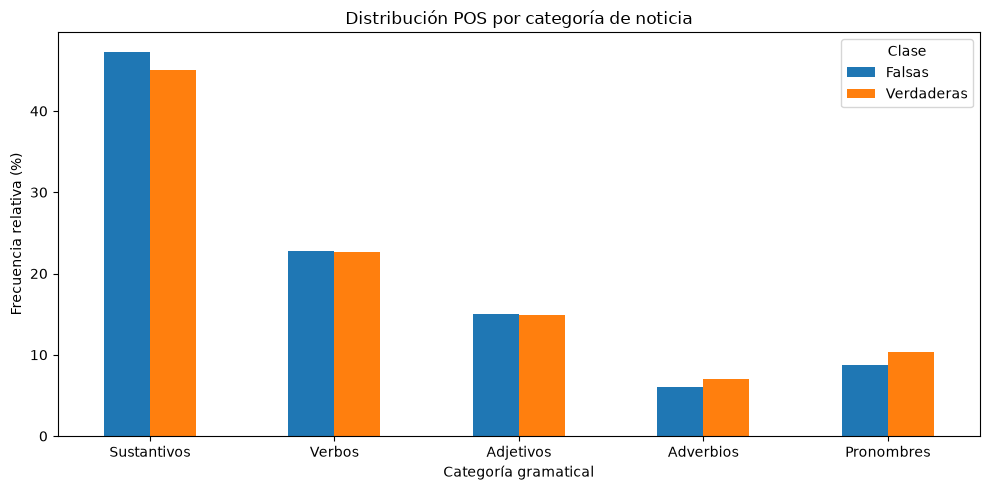

In [9]:
import matplotlib.pyplot as plt

pos_figure = plot_pos_distribution(pos_counts)
display(pos_figure)
RESULTS_POS_DIR = ROOT / "results" / "pos_ner"
RESULTS_POS_DIR.mkdir(parents=True, exist_ok=True)
pos_figure.savefig(RESULTS_POS_DIR / "pos_distribution.png", dpi=160, bbox_inches="tight")
plt.close(pos_figure)
pos_table.to_csv(RESULTS_POS_DIR / "pos_comparative_table.csv", encoding="utf-8")

In [10]:
top_nouns_true = top_words(word_counts, label=1, pos="NOUN", n=10)
top_nouns_false = top_words(word_counts, label=0, pos="NOUN", n=10)
top_verbs_true = top_words(word_counts, label=1, pos="VERB", n=10)
top_verbs_false = top_words(word_counts, label=0, pos="VERB", n=10)
top_adjectives_true = top_words(word_counts, label=1, pos="ADJ", n=10)
top_adjectives_false = top_words(word_counts, label=0, pos="ADJ", n=10)

display(top_nouns_true)
display(top_nouns_false)
display(top_verbs_true)
display(top_verbs_false)
display(top_adjectives_true)
display(top_adjectives_false)

,label,noticia,POS,token,frecuencia
0,1,Verdaderas,NOUN,año,857
1,1,Verdaderas,NOUN,país,562
2,1,Verdaderas,NOUN,presidente,454
3,1,Verdaderas,NOUN,persona,400
4,1,Verdaderas,NOUN,partido,363
5,1,Verdaderas,NOUN,gobierno,354
6,1,Verdaderas,NOUN,parte,351
7,1,Verdaderas,NOUN,día,337
8,1,Verdaderas,NOUN,caso,329
9,1,Verdaderas,NOUN,acuerdo,292


,label,noticia,POS,token,frecuencia
0,0,Falsas,NOUN,partido,502
1,0,Falsas,NOUN,vídeo,448
2,0,Falsas,NOUN,presidente,427
3,0,Falsas,NOUN,vers,399
4,0,Falsas,NOUN,año,388
5,0,Falsas,NOUN,persona,365
6,0,Falsas,NOUN,ley,331
7,0,Falsas,NOUN,caso,316
8,0,Falsas,NOUN,red,299
9,0,Falsas,NOUN,imagen,295


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,VERB,tener,999
1,1,Verdaderas,VERB,hacer,751
2,1,Verdaderas,VERB,decir,693
3,1,Verdaderas,VERB,pedir,386
4,1,Verdaderas,VERB,dar,367
5,1,Verdaderas,VERB,recibir,320
6,1,Verdaderas,VERB,seguir,301
7,1,Verdaderas,VERB,llegar,297
8,1,Verdaderas,VERB,ver,280
9,1,Verdaderas,VERB,asegurar,274


,label,noticia,POS,token,frecuencia
0,0,Falsas,VERB,tener,686
1,0,Falsas,VERB,hacer,496
2,0,Falsas,VERB,asegurar,413
3,0,Falsas,VERB,pedir,334
4,0,Falsas,VERB,decir,329
5,0,Falsas,VERB,afirmar,257
6,0,Falsas,VERB,dar,252
7,0,Falsas,VERB,señalar,207
8,0,Falsas,VERB,explicar,201
9,0,Falsas,VERB,presentar,191


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,ADJ,nuevo,537
1,1,Verdaderas,ADJ,primero,388
2,1,Verdaderas,ADJ,político,289
3,1,Verdaderas,ADJ,último,262
4,1,Verdaderas,ADJ,público,206
5,1,Verdaderas,ADJ,importante,196
6,1,Verdaderas,ADJ,social,182
7,1,Verdaderas,ADJ,mayor,170
8,1,Verdaderas,ADJ,solo,168
9,1,Verdaderas,ADJ,económico,167


,label,noticia,POS,token,frecuencia
0,0,Falsas,ADJ,nuevo,358
1,0,Falsas,ADJ,social,337
2,0,Falsas,ADJ,político,248
3,0,Falsas,ADJ,primero,247
4,0,Falsas,ADJ,español,220
5,0,Falsas,ADJ,público,208
6,0,Falsas,ADJ,último,196
7,0,Falsas,ADJ,general,172
8,0,Falsas,ADJ,viral,133
9,0,Falsas,ADJ,electoral,132


{'pos_counts': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/pos_ner/pos_frequencies.csv'),
 'word_counts': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/pos_ner/pos_token_frequencies.csv'),
 'table': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/pos_ner/pos_comparative_table.csv'),
 'figure': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/pos_ner/pos_distribution.png')}

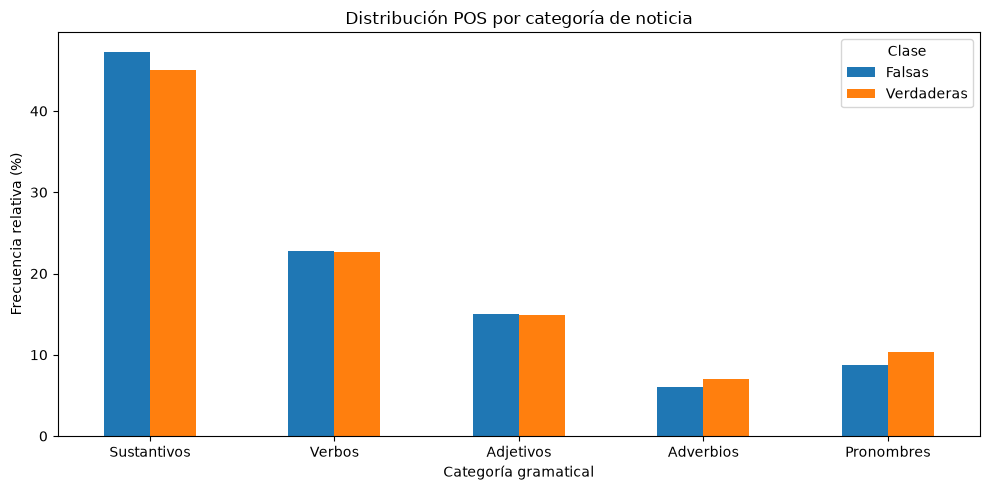

In [11]:
paths_pos = save_pos_results(pos_counts, word_counts, RESULTS_POS_DIR)
paths_pos

### Interpretación inicial

La tabla y el gráfico permiten comparar la proporción de cada categoría respecto del total de tokens de las cinco categorías analizadas en cada clase. Si se dividiera entre todos los tokens del corpus, las proporciones no sumarían 100% porque se omitirían otras etiquetas POS, como determinantes, artículos, adposiciones y conjunciones. Las diferencias deben interpretarse junto con la longitud y el tema de las noticias: una mayor frecuencia relativa no demuestra por sí sola que una categoría gramatical sea un indicador suficiente de falsedad.

## 4. Reconocimiento de Entidades Nombradas (NER)

Se extraen las entidades reconocidas por spaCy sobre el texto crudo. Cada fila representa una menci?n y conserva el documento, la clase, el texto de la entidad y su tipo. Las repeticiones se mantienen porque son necesarias para calcular frecuencias.

In [12]:
from src.pos_ner import (
    extract_entities,
    summarize_entities,
    entity_type_distribution,
    top_global_entities,
    plot_ner_distribution,
    plot_top_entities,
    save_ner_results,
)

ner_entities = extract_entities(metadata, nlp, text_column="text", label_column="label")
ner_summaries = summarize_entities(ner_entities, top_n=10)

print(f"Menciones detectadas: {len(ner_entities):,}")
print(f"Documentos con entidades: {ner_entities['doc_id'].nunique():,}")
display(ner_entities.head())

Menciones detectadas: 50,648
Documentos con entidades: 5,286


,doc_id,label,clase,entidad,tipo
0,ds_falso_0001,0,Falsas,Gobierno andaluz,LOC
1,ds_falso_0001,0,Falsas,Junta,MISC
2,ds_falso_0001,0,Falsas,Consejería de Agricultura,LOC
3,ds_falso_0001,0,Falsas,Carmen Crespo,PER
4,ds_falso_0001,0,Falsas,BNG,ORG


In [13]:
# Total de entidades y distribuci?n porcentual por tipo dentro de cada clase.
ner_by_class = ner_summaries["by_class"]
ner_type_distribution = entity_type_distribution(ner_entities)
display(ner_by_class)
display(ner_type_distribution)

,label,clase,menciones,entidades_unicas,documentos
0,0,Falsas,24207,8025,2646
1,1,Verdaderas,26441,9994,2640


,label,clase,tipo,menciones,documentos,porcentaje
0,0,Falsas,LOC,7643,2084,31.573512
1,0,Falsas,PER,6091,2242,25.162143
2,0,Falsas,MISC,5690,2041,23.505598
3,0,Falsas,ORG,4783,1867,19.758747
4,1,Verdaderas,LOC,8765,2072,33.149276
5,1,Verdaderas,MISC,6651,2015,25.154117
6,1,Verdaderas,PER,6617,1878,25.025529
7,1,Verdaderas,ORG,4408,1733,16.671079


In [14]:
# Diez entidades m?s frecuentes por tipo para cada clase.
ner_top_by_type = ner_summaries["top_entities"]
display(ner_top_by_type[ner_top_by_type["label"] == 1])
display(ner_top_by_type[ner_top_by_type["label"] == 0])

,label,clase,tipo,entidad,frecuencia
40,1,Verdaderas,LOC,Gobierno,343
41,1,Verdaderas,LOC,EE.UU.,245
42,1,Verdaderas,LOC,Venezuela,245
43,1,Verdaderas,LOC,Colombia,160
44,1,Verdaderas,LOC,Estados Unidos,151
45,1,Verdaderas,LOC,Madrid,149
46,1,Verdaderas,LOC,Estado,136
47,1,Verdaderas,LOC,Reino Unido,96
48,1,Verdaderas,LOC,Cuba,92
49,1,Verdaderas,LOC,Argentina,88


,label,clase,tipo,entidad,frecuencia
0,0,Falsas,LOC,Ceuta,619
1,0,Falsas,LOC,Gobierno,506
2,0,Falsas,LOC,Marruecos,236
3,0,Falsas,LOC,Madrid,216
4,0,Falsas,LOC,Coalición Canaria,205
5,0,Falsas,LOC,España,190
6,0,Falsas,LOC,Nueva Canarias,184
7,0,Falsas,LOC,Qué,126
8,0,Falsas,LOC,Melilla,96
9,0,Falsas,LOC,Comunidad de Madrid,92


In [15]:
# Veinte entidades m?s frecuentes globalmente por categor?a.
ner_top_true = top_global_entities(ner_entities, label=1, n=20)
ner_top_false = top_global_entities(ner_entities, label=0, n=20)
display(ner_top_true)
display(ner_top_false)

,label,clase,entidad,frecuencia
0,1,Verdaderas,PP,590
1,1,Verdaderas,Gobierno,394
2,1,Verdaderas,PSOE,330
3,1,Verdaderas,EE.UU.,245
4,1,Verdaderas,Venezuela,245
5,1,Verdaderas,Vox,231
6,1,Verdaderas,Congreso,181
7,1,Verdaderas,España,178
8,1,Verdaderas,También,174
9,1,Verdaderas,Colombia,160


,label,clase,entidad,frecuencia
0,0,Falsas,Ceuta,619
1,0,Falsas,Gobierno,566
2,0,Falsas,Iniciativa vers per Catalunya,474
3,0,Falsas,España,393
4,0,Falsas,PP,310
5,0,Falsas,BNG,279
6,0,Falsas,Cristina Narbona,245
7,0,Falsas,Congreso,237
8,0,Falsas,EQUO,236
9,0,Falsas,Marruecos,236


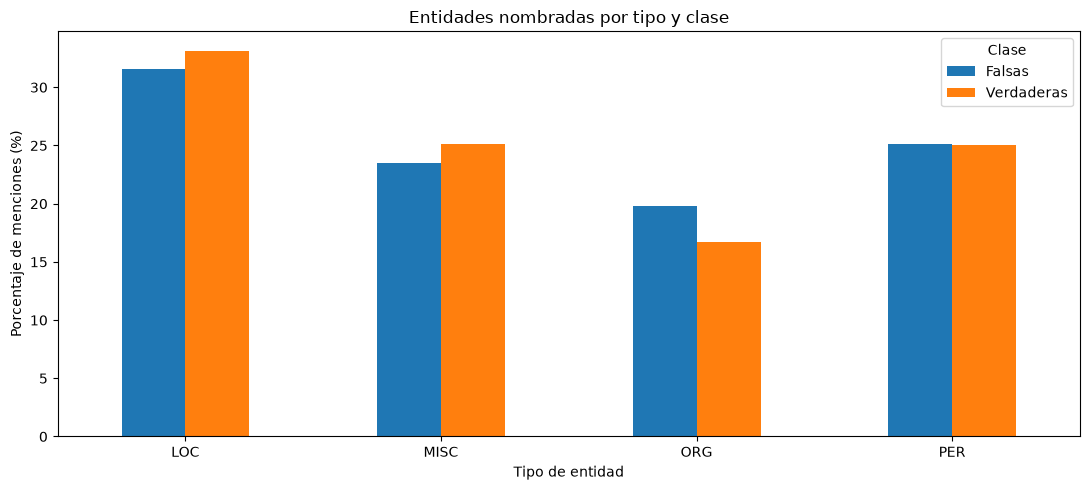

In [16]:
import matplotlib.pyplot as plt

RESULTS_NER_DIR = ROOT / "results" / "ner"
RESULTS_NER_DIR.mkdir(parents=True, exist_ok=True)

ner_distribution_figure = plot_ner_distribution(ner_entities)
display(ner_distribution_figure)
ner_distribution_figure.savefig(RESULTS_NER_DIR / "ner_distribution.png", dpi=160, bbox_inches="tight")
plt.close(ner_distribution_figure)

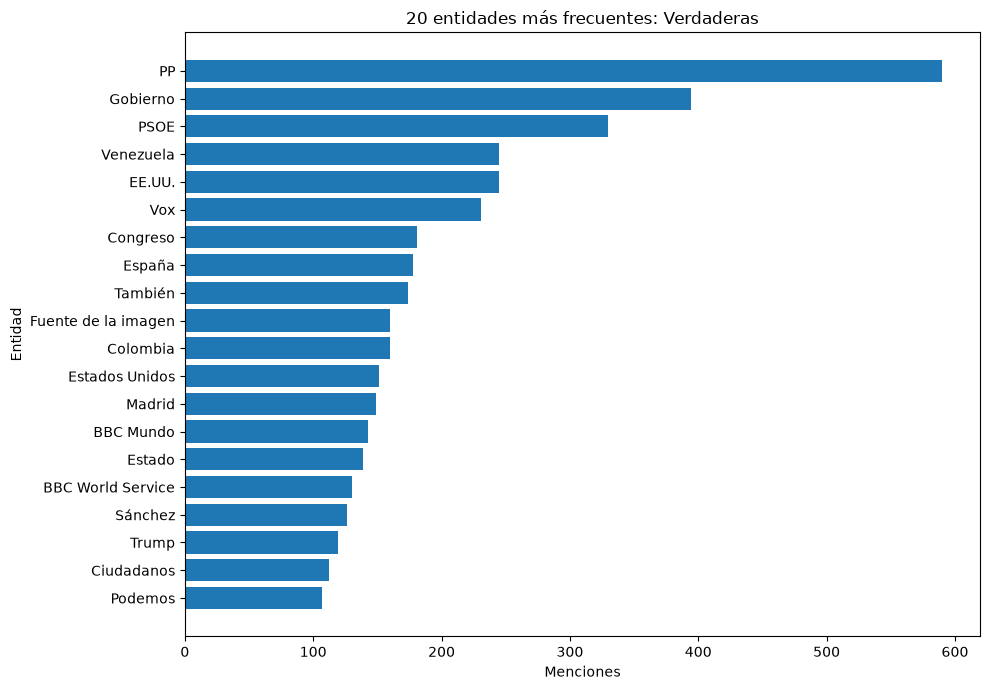

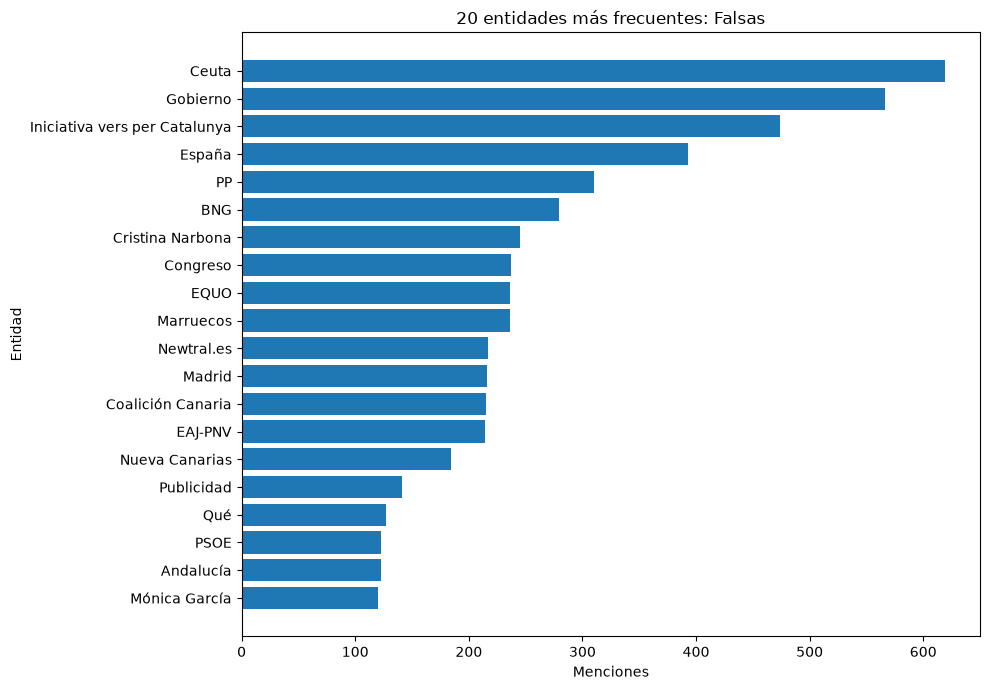

In [17]:
true_figure = plot_top_entities(ner_entities, label=1, n=20)
false_figure = plot_top_entities(ner_entities, label=0, n=20)
display(true_figure)
display(false_figure)
true_figure.savefig(RESULTS_NER_DIR / "ner_top_verdaderas.png", dpi=160, bbox_inches="tight")
false_figure.savefig(RESULTS_NER_DIR / "ner_top_falsas.png", dpi=160, bbox_inches="tight")
plt.close(true_figure)
plt.close(false_figure)

{'entities': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_entities.csv'),
 'summary': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_summary.csv'),
 'by_type': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_by_type.csv'),
 'top_entities': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_top_entities.csv'),
 'by_class': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_by_class.csv'),
 'type_distribution': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_type_distribution.csv'),
 'top_global_true': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_top_global_verdaderas.csv'),
 'top_global_false': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_top_global_falsas.csv'),
 'figure': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_distribution.png'),
 'figure_true': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/ner/ner_top_verdaderas.png'),
 'figure_false': WindowsPath('C:/UNI/2026-2/PLN/Practica01/r

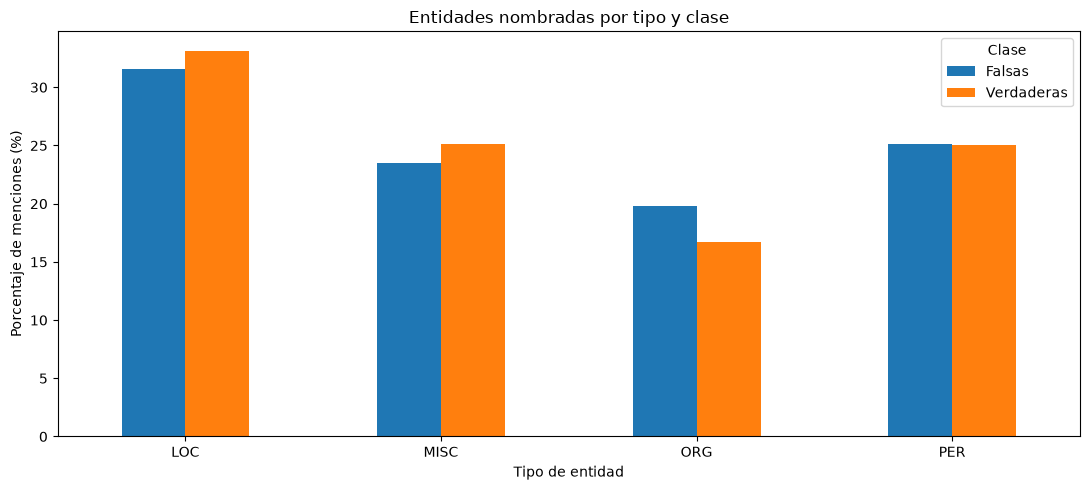

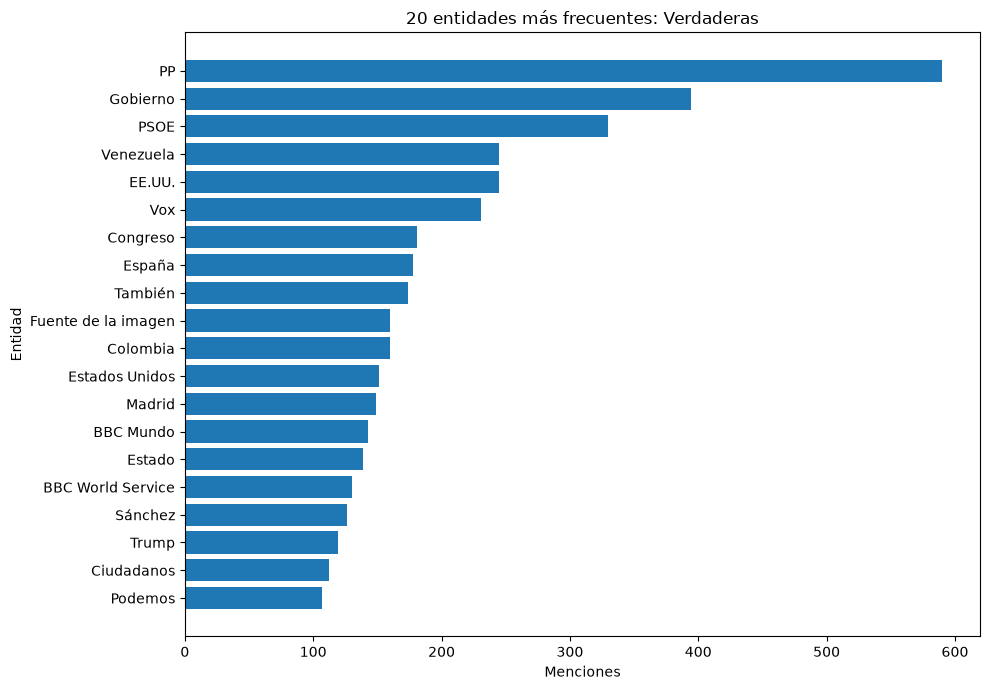

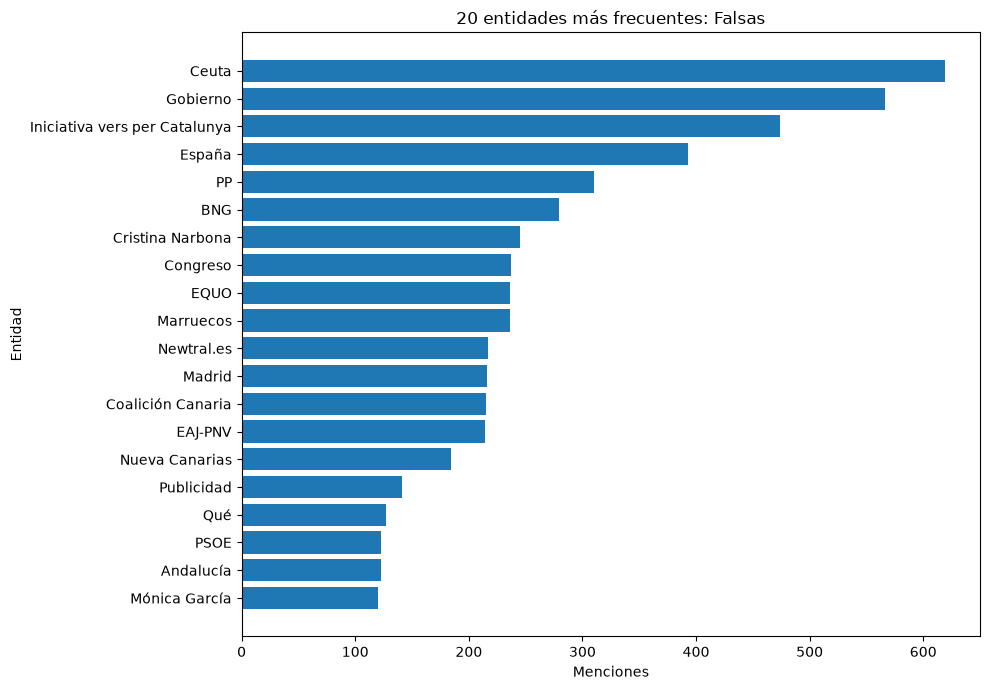

In [18]:
ner_paths = save_ner_results(ner_entities, RESULTS_NER_DIR, top_n=10)
ner_paths

### Revisi?n de errores del modelo

Las predicciones de NER no incluyen una anotaci?n de referencia en el corpus, por lo que los errores deben validarse manualmente. Para el informe se deben seleccionar al menos cinco casos de `ner_entities` y documentar si son falsos positivos, categor?as incorrectas o entidades omitidas. La revisi?n debe incluir el fragmento original, la predicci?n del modelo, la categor?a esperada y la justificaci?n.

## 5. Extracción de características

En esta sección se usarán unigramas, bigramas, stopwords, stemming, términos de ocurrencia y TF-IDF mediante `src/features.py`.

## 6. Modelado de temas

En esta sección se ejecutarán LSA, LDA y las métricas de coherencia mediante `src/topics.py`.

## 7. Clasificación

En esta sección se compararán cuatro algoritmos y ocho configuraciones usando validación cruzada mediante `src/classify.py`.